Epoch 1/10 | Loss: 0.3592 | Train Acc: 90.19%
Test Accuracy: 94.11%

Epoch 2/10 | Loss: 0.1679 | Train Acc: 95.18%
Test Accuracy: 96.10%

Epoch 3/10 | Loss: 0.1178 | Train Acc: 96.58%
Test Accuracy: 96.68%

Epoch 4/10 | Loss: 0.0889 | Train Acc: 97.41%
Test Accuracy: 97.12%

Epoch 5/10 | Loss: 0.0714 | Train Acc: 97.86%
Test Accuracy: 97.36%

Epoch 6/10 | Loss: 0.0568 | Train Acc: 98.32%
Test Accuracy: 97.61%

Epoch 7/10 | Loss: 0.0466 | Train Acc: 98.66%
Test Accuracy: 97.69%

Epoch 8/10 | Loss: 0.0385 | Train Acc: 98.89%
Test Accuracy: 97.69%

Epoch 9/10 | Loss: 0.0339 | Train Acc: 98.99%
Test Accuracy: 97.58%

Epoch 10/10 | Loss: 0.0264 | Train Acc: 99.27%
Test Accuracy: 97.65%



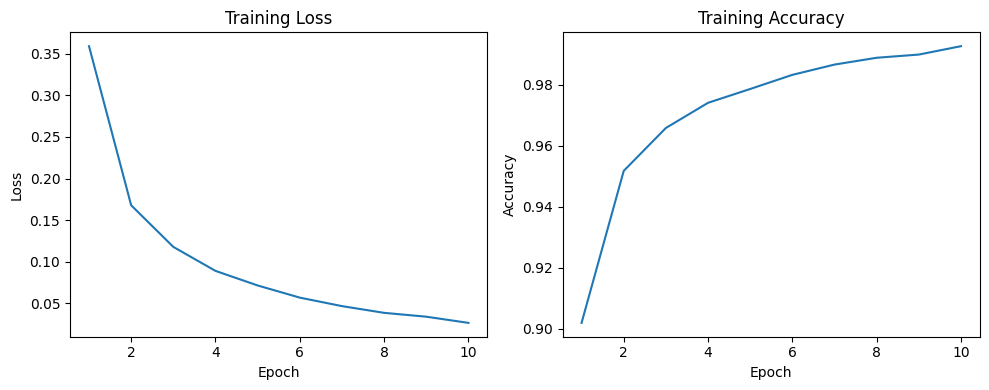

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======================
# Load dataset
# ======================
train_data = MNIST(root="data", train=True, transform=ToTensor(), download=True)
test_data = MNIST(root="data", train=False, transform=ToTensor())

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

# ======================
# Model ANN
# ======================
class DigitClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self,x):
        return self.network(x)

model = DigitClassifier().to(device)

# ======================
# Loss + Optimizer
# ======================
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

# ======================
# Training
# ======================
num_epochs = 10
train_loss_history = []
train_acc_history = []

for epoch in range(num_epochs):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images,labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        preds = model(images)

        loss = loss_fn(preds,labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(preds,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = total_loss / len(train_loader)
    epoch_acc = correct / total

    train_loss_history.append(epoch_loss)
    train_acc_history.append(epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")

    # ======================
    # Test accuracy
    # ======================
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images,labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = correct / total

    print(f"Test Accuracy: {test_acc*100:.2f}%\n")


# ======================
# Plot
# ======================
epochs = range(1,num_epochs+1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(epochs,train_loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(epochs,train_acc_history)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# Giải thích đơn giản code ANN phân loại MNIST (PyTorch)

## 1. Import thư viện

``` python
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
```

Các thư viện chính:

-   **torch**: thư viện deep learning PyTorch
-   **torch.nn**: dùng để xây dựng các lớp mạng neural network
-   **torch.optim**: chứa các thuật toán tối ưu (optimizer)
-   **torchvision.datasets**: chứa các bộ dữ liệu phổ biến như MNIST
-   **DataLoader**: giúp chia dữ liệu thành từng batch
-   **matplotlib**: dùng để vẽ biểu đồ

------------------------------------------------------------------------

# 2. Chọn thiết bị chạy (GPU hoặc CPU)

``` python
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
```

-   Nếu máy có **GPU** → dùng GPU để train nhanh hơn
-   Nếu không → dùng **CPU**

------------------------------------------------------------------------

# 3. Load dữ liệu MNIST

``` python
train_data = MNIST(root="data", train=True, transform=ToTensor(), download=True)
test_data = MNIST(root="data", train=False, transform=ToTensor())
```

MNIST là bộ dữ liệu gồm:

-   **60000 ảnh train**
-   **10000 ảnh test**
-   mỗi ảnh kích thước **28 x 28**
-   phân loại **10 chữ số (0--9)**

`ToTensor()` chuyển ảnh thành tensor để PyTorch xử lý.

------------------------------------------------------------------------

# 4. Tạo DataLoader

``` python
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)
```

DataLoader giúp:

-   chia dữ liệu thành **batch**
-   mỗi batch có **64 ảnh**
-   `shuffle=True` giúp trộn dữ liệu khi train

------------------------------------------------------------------------

# 5. Xây dựng mô hình ANN

``` python
class DigitClassifier(nn.Module):
```

Đây là mô hình **Artificial Neural Network**.

Cấu trúc mạng:

    Input (784)
       ↓
    Linear (128)
       ↓
    ReLU
       ↓
    Linear (10)
       ↓
    Output

Giải thích:

-   **Flatten**: biến ảnh 28x28 → vector 784
-   **Linear(784,128)**: layer fully connected
-   **ReLU**: hàm kích hoạt
-   **Linear(128,10)**: output 10 lớp (0--9)

------------------------------------------------------------------------

# 6. Hàm Loss và Optimizer

``` python
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
```

### CrossEntropyLoss

Dùng cho bài toán **classification**.

### Adam optimizer

Thuật toán tối ưu giúp cập nhật trọng số của mô hình.

------------------------------------------------------------------------

# 7. Training mô hình

``` python
for epoch in range(num_epochs):
```

Huấn luyện mô hình qua nhiều **epoch**.

Trong mỗi batch:

1.  Đưa ảnh vào model
2.  Tính **loss**
3.  Tính **gradient**
4.  Cập nhật trọng số

``` python
loss.backward()
optimizer.step()
```

------------------------------------------------------------------------

# 8. Tính Accuracy

Sau mỗi epoch:

-   đếm số dự đoán đúng
-   chia cho tổng số mẫu

``` python
correct += (predicted == labels).sum().item()
accuracy = correct / total
```

------------------------------------------------------------------------

# 9. Đánh giá trên tập test

Model chuyển sang chế độ:

``` python
model.eval()
```

và tắt gradient:

``` python
with torch.no_grad():
```

để giảm tốn bộ nhớ và tăng tốc.

------------------------------------------------------------------------

# 10. Vẽ biểu đồ

``` python
plt.plot(train_loss_history)
plt.plot(train_acc_history)
```

Hai biểu đồ:

1.  **Training Loss**
2.  **Training Accuracy**

Giúp quan sát quá trình học của mô hình.

------------------------------------------------------------------------

# Kết quả mong đợi

Sau khi train:

-   **Train Accuracy \~ 97--99%**
-   **Test Accuracy \~ 96--98%**

Điều này cho thấy mô hình ANN đã học tốt cách nhận diện chữ số viết tay.
